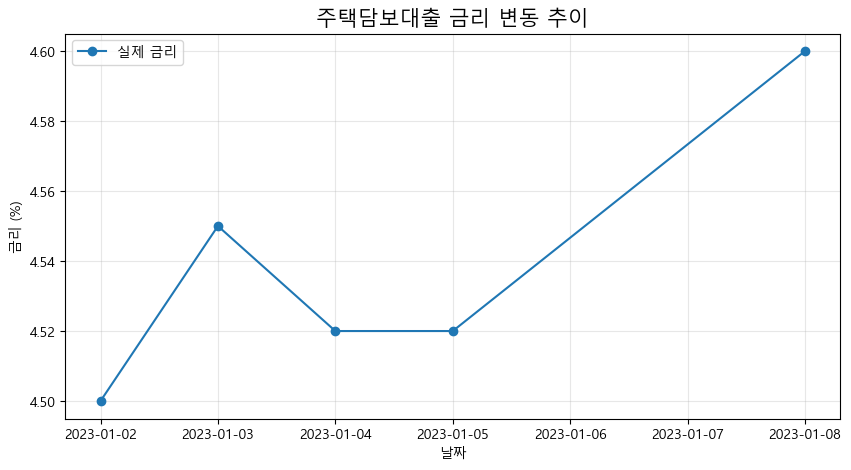

최근 평균 금리: 4.54%
총 대출 실행액: 6,500억 원


In [ ]:
# 🟢빈칸, to_datetime 서로 다른 형식의 날짜
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 가상의 주택금융 데이터 생성
# 날짜 🍋형식이 뒤섞여 있고 빈칸(NaN)이 있는 상황, 
data = {
    '날짜': ['2023-01-02', '2023/01/03', '2023.01.05', '2023-01-04', '2023-01-08'],
    '금리': [4.5, 4.55, np.nan, 4.52, 4.6],
    '대출실행액': [1200, 1500, 1100, 1300, 1400]
}
df = pd.DataFrame(data)

# 2. 데이터 전처리 # format='mixed' 서로 🟢다른 형식의 날짜 문자열 유연하게 처리
df['날짜'] = pd.to_datetime(df['날짜'], format='mixed') # 문자열을 날짜 형식으로 변환
df = df.sort_values('날짜') # 날짜 순서대로 정렬
df['금리'] = df['금리'].ffill() # 🟢결측치를 이전 날짜 값으로 🍋채우기 (금융권 방식)

# 3. 시각화 p389
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 5))
plt.plot(df['날짜'], df['금리'], marker='o', label='실제 금리', color='#1f77b4')
# plt.plot(df['날짜'], df['금리_이동평균'], linestyle='--', label='3일 추세선', color='#ff7f0e')

plt.title('주택담보대출 금리 변동 추이', fontsize=15) #pad=20, fontweight='bold'
plt.xlabel('날짜')
plt.ylabel('금리 (%)')
plt.legend() #3️⃣loc='lower left' 'upper right' 'best'선택해보기 fontsize=20, frameon=False
plt.grid(True, alpha=0.3) # linestyle=':'  axis='y' 아주연하게 가로선만
plt.show()

# 5. 요약 보고
print(f"최근 평균 금리: {df['금리'].mean():.2f}%")
print(f"총 대출 실행액: {df['대출실행액'].sum():,}억 원")


# ffill() (Forward Fill): 금융 데이터에서 주말이나 공휴일 때문에 비어있는 금리 값을 직전 영업일 값으로 채우는
# rolling(): 단순 수치가 아니라 '추세'를 봐야 하는 경영진의 니즈를 충족시키는 핵심 함수입니다.
